# **SQL–YoY Superstore Dataset Analysis** / ***SQL-Menganalisa YoY Superstore Dataset***

## **Introduction**/ ***Pendahuluan***

Pada analisis data kali ini adalah menganalisa data penjualan superstore untuk mengindentifikasi penjualan, profit, margin dan perkembangan margin dari tahun ke tahun Year of Year (YoY). Sekilas tentang data ini memiliki berapa data transaksi penjualan dari periode tahun 2014 – 2017, dengan total data 9,994 baris, dan 21 kolom. Dataset mendukung kalian dalam melatih dalam menganalisa data penjualan dari berbagai aspek seperti penjualan tahunan, penjualan bulanan, penjualan berdasarkan customer, kota, produk dan sebagainya yang mana untuk memahami perkembangan bisnis di superstore.
_____

In this data analysis, I will analyze superstore sales data to identify sales, profit, margins, and year-over-year (YoY) margin trends. This dataset contains sales transaction data from the 2014–2017 period, with a total of 9,994 rows and 21 columns. The dataset helps you practice analyzing sales data from various perspectives—such as annual sales, monthly sales, sales by customer, city, product, and so on—to understand business trends at the superstore.
___

Informasi Dataset / Dataset Information
1. Row ID 
2. Order ID
3. Order Date
4. Ship Date
5. Ship Mode
6. Customer ID 
7. Customer Name
8. Segment
9. Country
10. City
11. State
12. Postal Code
13. Region
14. Product ID
15. Category
16.	Sub-Category
17.	Product Name
18.	Sales
19.	Quantity
20.	Discount
21.	Profit




## **Objectives** / ***Tujuan***
### **1. Data Exploration & Profiling Data / Eksplorasi & Profiling Data*
    • Data Type & Schema Audit / Audit Tipe Data & Skema
    • Distinct Value Count per Column / Jumlah Nilai Unik per Kolom
    • Row Count per Partition / per Tanggal
    • Cardinality Check (Low vs High Cardinality)
    • Duplicate Row Detector
    • Value Constraint Checker

### **2. Data Cleaning / Pembersihan Data :**
    • Ubah tipe data tanggal dari varchar ke tanggal / Convert the date data type from varchar to date

### **3. YoY Analysis & Modelling / Analisa YoY & Modeling**
    • Menganalisa total penjualan dan profit per tahun /Analyze total annual sales and profit
    • Menghitung Margin per tahun / Calculate the annual margin
    • Menghitung persentase perkembangan penjualan, profit dan margin selama setahun /Calculate the percentage growth in sales, profit, and margin over the course of a year


#### Library

In [5]:
import os
import sys
import io
import warnings
from datetime import datetime
warnings.filterwarnings('ignore')
import duckdb
import pandas as pd
import numpy as np
import matplotlib
from matplotlib.gridspec import GridSpec
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from matplotlib.backends.backend_pdf import PdfPages
import seaborn as sns
from PIL import Image
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Style settings
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 10

cursor = duckdb.connect()
print (cursor.execute('SELECT 42').fetchall())

[(42,)]


In [6]:
db_store = pd.read_csv('Sample - Superstore.csv', encoding='latin-1')

In [7]:
duckdb.sql ("CREATE TABLE stores AS SELECT * FROM db_store")

In [8]:
db_store.head ()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


### Data Exploration & Profiling Data Cleaning / Eksplorasi & Profiling Data

#### Data Type & Schema Audit / Audit Tipe Data & Skema

In [11]:
db_store.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

In [12]:
q_dtype = """
SELECT
    column_name,
    data_type,
    is_nullable,
    NULL AS is_partitioning_column,
    NULL AS clustering_oridinal_position
FROM INFORMATION_SCHEMA.COLUMNS WHERE table_name = 'stores'
"""
dtyp = duckdb.sql (q_dtype ).df()
dtyp


,column_name,data_type,is_nullable,is_partitioning_column,clustering_oridinal_position
0,Row ID,BIGINT,YES,<NA>,<NA>
1,Order ID,VARCHAR,YES,<NA>,<NA>
2,Order Date,VARCHAR,YES,<NA>,<NA>
3,Ship Date,VARCHAR,YES,<NA>,<NA>
4,Ship Mode,VARCHAR,YES,<NA>,<NA>
5,Customer ID,VARCHAR,YES,<NA>,<NA>
6,Customer Name,VARCHAR,YES,<NA>,<NA>
7,Segment,VARCHAR,YES,<NA>,<NA>
8,Country,VARCHAR,YES,<NA>,<NA>
9,City,VARCHAR,YES,<NA>,<NA>


In [13]:
# RESULTS

def type_summary ():
    data_types = {
        'Order Date' : 'object/varchar → datetime64/TIMESTAMP, DATE',
        'Ship Date' : 'object/varchar → datetime64/TIMESTAMP, DATE',
        'Postal Code' : 'BIGINT/int64 → object/varchar,text',
        'Sales' : 'Double/float64 → decimal',
        'Discount' : 'Double/float64 → decimal',
        'Profit' : 'Double/float64 → decimal'    
    }    
    print("="*90)
    print(f"\033[1mDATA TYPE SUMMARY\033[0m".center(80))
    print("="*90)
    
    for col, data_types in data_types.items():
        print(f" {col:20} → {data_types} ")
    print("\n" + "="*90)
    
type_summary()

                           DATA TYPE SUMMARY                            
 Order Date           → object/varchar → datetime64/TIMESTAMP, DATE 
 Ship Date            → object/varchar → datetime64/TIMESTAMP, DATE 
 Postal Code          → BIGINT/int64 → object/varchar,text 
 Sales                → Double/float64 → decimal 
 Discount             → Double/float64 → decimal 
 Profit               → Double/float64 → decimal 



#### Distinct Value Count per Kolom

In [15]:
q_dvalue = """
SELECT 
   COUNT (*) AS total_rows,
    COUNT (DISTINCT "Order ID") AS order_id,
    COUNT (DISTINCT "Ship Mode") AS ship_mode,
    COUNT (DISTINCT "Customer ID") AS customer_id,
    COUNT (DISTINCT "Customer Name") AS customer_name,
    COUNT (DISTINCT "Segment") AS segment,
    COUNT (DISTINCT "City") AS city,
    COUNT (DISTINCT "State") AS state,
    COUNT (DISTINCT "Postal Code") AS postal_code,
    COUNT (DISTINCT "Region") AS region,
    COUNT (DISTINCT "Product ID") AS product_id,
    COUNT (DISTINCT "Category") AS category,
    COUNT (DISTINCT "Sub-Category") AS sub_category,
    COUNT (DISTINCT "Product Name") AS product_name,
FROM stores 

"""

ddvalue = duckdb.sql (q_dvalue).df()
ddvalue



,total_rows,order_id,ship_mode,customer_id,customer_name,segment,city,state,postal_code,region,product_id,category,sub_category,product_name
0,9994,5009,4,793,793,3,531,49,631,4,1862,3,17,1850


In [16]:
#SUMMARY Distinct Value Count per Kolom

def dvalue_summary ():
    sum_dvalue = {
        "Total Rows" : f"{ddvalue['total_rows'].iloc[0]:,}",
        "Order ID" : f"{ddvalue['order_id'].iloc[0]:,}",
        "Ship Mode" : f"{ddvalue['ship_mode'].iloc[0]:,}",
        "Customer ID" : f"{ddvalue['customer_id'].iloc[0]:,}",
        "Customer Name" : f"{ddvalue['customer_name'].iloc[0]:,}",
        "Segment" : f"{ddvalue['segment'].iloc[0]:,}",
        "City" : f"{ddvalue['city'].iloc[0]:,}",
        "State" : f"{ddvalue['state'].iloc[0]:,}",
        "Postal Code" : f"{ddvalue['postal_code'].iloc[0]:,}",
        "Region" : f"{ddvalue['region'].iloc[0]:,}",
        "Product ID" : f"{ddvalue['product_id'].iloc[0]:,}",
        "Product Name" : f"{ddvalue['product_name'].iloc[0]:,}",
        "Category" : f"{ddvalue['category'].iloc[0]:,}",
        "Sub Category" : f"{ddvalue['sub_category'].iloc[0]:,}"
     }
    # Header
    print("="*80)
    print(f"\033[1mUNIQUE VALUE COUNT SUMMARY\033[0m".center(80))
    print("="*80)
    print(f"{'METRIC':>15} {'VALUE':>15}")
    print("-"*40)

    #DATA
    for col, sum_dvalue in sum_dvalue.items():  
        print(f"{col:20} : {sum_dvalue}")
    print("="*80)
dvalue_summary()

                       UNIQUE VALUE COUNT SUMMARY                       
         METRIC           VALUE
----------------------------------------
Total Rows           : 9,994
Order ID             : 5,009
Ship Mode            : 4
Customer ID          : 793
Customer Name        : 793
Segment              : 3
City                 : 531
State                : 49
Postal Code          : 631
Region               : 4
Product ID           : 1,862
Product Name         : 1,850
Category             : 3
Sub Category         : 17


#### Row Count per Partition / per Tanggal

In [18]:
q_rcount = """
SELECT 
    COUNT (*) AS total_rows,
    COUNT (DISTINCT "Order ID") AS uniq_order_id,
    COUNT (*) - COUNT (DISTINCT "Order ID") AS dupl_order_id_count,
    COUNT (DISTINCT "Customer ID") AS uniq_cus_id,
    COUNT (*) - COUNT (DISTINCT "Customer ID") AS dupl_cus_id_count,
    COUNT (DISTINCT "Product ID") AS uniq_pro_id,
    COUNT (*) - COUNT (DISTINCT "Product ID") AS dupl_pro_id_count,
    COUNT (DISTINCT "City") AS uniq_city,
    COUNT (*) - COUNT (DISTINCT "City") AS dupl_city_count,
    MIN (CAST(strptime("Order Date", '%m/%d/%Y') AS DATE)) AS order_earliest_record,
    MAX (CAST(strptime("Order Date", '%m/%d/%Y') AS DATE)) AS order_latest_record,
    DATE_DIFF('day', MIN(strptime("Order Date", '%m/%d/%Y')), MAX(strptime("Order Date", '%m/%d/%Y'))) AS orderdate_span_days,
    MIN (CAST(strptime("Ship Date", '%m/%d/%Y') AS DATE)) AS ship_earliest_record,
    MAX (CAST(strptime("Ship Date", '%m/%d/%Y') AS DATE)) AS ship_latest_record,
    DATE_DIFF('day', MIN(strptime("Ship Date", '%m/%d/%Y')), MAX(strptime("Ship Date", '%m/%d/%Y'))) AS shipdate_span_days
FROM stores 

"""

drcount = duckdb.sql (q_rcount).df()
drcount

,total_rows,uniq_order_id,dupl_order_id_count,uniq_cus_id,dupl_cus_id_count,uniq_pro_id,dupl_pro_id_count,uniq_city,dupl_city_count,order_earliest_record,order_latest_record,orderdate_span_days,ship_earliest_record,ship_latest_record,shipdate_span_days
0,9994,5009,4985,793,9201,1862,8132,531,9463,2014-01-03,2017-12-30,1457,2014-01-07,2018-01-05,1459


In [19]:
#SUMMARY Row Count per Partition / per Tanggal

def rdate_summary ():
    sum_datevalue = {
        "Total Rows" : f"{drcount['total_rows'].iloc[0]:,}",
        "Unique Order ID" : f"{drcount['uniq_order_id'].iloc[0]:,}",
        "Duplicate Order ID" : f"{drcount['dupl_order_id_count'].iloc[0]:,}",
        "Unique Customer ID" : f"{drcount['uniq_cus_id'].iloc[0]:,}",
        "Duplicate Customer ID" : f"{drcount['dupl_cus_id_count'].iloc[0]:,}",
        "Unique City" : f"{drcount['uniq_city'].iloc[0]:,}",
        "Duplicate City" : f"{drcount['dupl_city_count'].iloc[0]:,}",
        "Order Earliest Record" : f"{drcount['order_earliest_record'].iloc[0].date()}",
        "Order Lateest Record" : f"{drcount['order_latest_record'].iloc[0].date()}",
        "Order Span Days" : f"{drcount['orderdate_span_days'].iloc[0]:,}",
        "Ship Earliest Record" : f"{drcount['ship_earliest_record'].iloc[0].date()}",
        "Ship Lateest Record" : f"{drcount['ship_latest_record'].iloc[0].date()}",
        "Ship Span Days" : f"{drcount['shipdate_span_days'].iloc[0]:,}"

     }
    # Header
    print( "="*80)
    print(f"\033[1mROW COUNT PER PARTITION SUMMARY\033[0m".center(80))
    print("="*80)
    print(f"{'METRIC':>15} {'VALUE':>20}")
    print("-"*45)

    #DATA
    for col, sum_datevalue in sum_datevalue.items():  
        print(f"{col:25} : {sum_datevalue}")
    print("="*80)
rdate_summary()

                    ROW COUNT PER PARTITION SUMMARY                     
         METRIC                VALUE
---------------------------------------------
Total Rows                : 9,994
Unique Order ID           : 5,009
Duplicate Order ID        : 4,985
Unique Customer ID        : 793
Duplicate Customer ID     : 9,201
Unique City               : 531
Duplicate City            : 9,463
Order Earliest Record     : 2014-01-03
Order Lateest Record      : 2017-12-30
Order Span Days           : 1,457
Ship Earliest Record      : 2014-01-07
Ship Lateest Record       : 2018-01-05
Ship Span Days            : 1,459


#### Cardinality Check (Low vs High Cardinality)

In [21]:
q_cardinality = """
WITH stats AS (
SELECT 
    COUNT (*) AS total_rows,
    COUNT (DISTINCT "Order ID") AS order_card,
    COUNT (DISTINCT "Customer ID") AS cus_card,
    COUNT (DISTINCT "City") AS city_card,
    COUNT (DISTINCT "State") AS state_card,
    COUNT (DISTINCT "Region") AS region_card,
    COUNT (DISTINCT "Product ID") AS product_id_card,
    COUNT (DISTINCT "Product Name") AS product_name_card,
    COUNT (DISTINCT "Category") AS category_card
FROM stores 
)
SELECT 
    'CARDINALITY REPORT' AS report_type,
    total_rows,
    column_name,
    unique_count,
    ROUND(100.0 * unique_count/ total_rows, 2) AS ratio_pct,
    CASE 
        WHEN (1.0 * unique_count / total_rows) < 0.01 THEN 'Very Low — ideal dimension/flag (<1%)'
        WHEN (1.0 * unique_count / total_rows) < 0.05 THEN 'Low — good dimension (1-5%)'
        WHEN (1.0 * unique_count / total_rows) < 0.30 THEN 'Medium — use with caution (5-30%)'
        WHEN (1.0 * unique_count / total_rows) < 0.90 THEN 'High — probably not a dimension (30-90%)'
        ELSE 'Very High — likely an ID/key (>90%)'
    END AS order_cardinality   
FROM stats
UNPIVOT (
    unique_count FOR column_name IN (
        order_card AS 'Order ID',
        cus_card AS 'Customer ID',
        city_card AS 'City',
        state_card AS 'State',
        region_card AS 'Region',
        product_id_card AS 'Product ID',
        product_name_card AS 'Product Name',
        category_card AS 'Category'
    )    
)
ORDER BY ratio_pct DESC;
"""

dcardinality = duckdb.sql (q_cardinality).df()
dcardinality



,report_type,total_rows,column_name,unique_count,ratio_pct,order_cardinality
0,CARDINALITY REPORT,9994,Order ID,5009,50.12,High — probably not a dimension (30-90%)
1,CARDINALITY REPORT,9994,Product ID,1862,18.63,Medium — use with caution (5-30%)
2,CARDINALITY REPORT,9994,Product Name,1850,18.51,Medium — use with caution (5-30%)
3,CARDINALITY REPORT,9994,Customer ID,793,7.93,Medium — use with caution (5-30%)
4,CARDINALITY REPORT,9994,City,531,5.31,Medium — use with caution (5-30%)
5,CARDINALITY REPORT,9994,State,49,0.49,Very Low — ideal dimension/flag (<1%)
6,CARDINALITY REPORT,9994,Region,4,0.04,Very Low — ideal dimension/flag (<1%)
7,CARDINALITY REPORT,9994,Category,3,0.03,Very Low — ideal dimension/flag (<1%)


In [22]:
# SUMMARY

# FUNGSI PROGRESS BAR

def create_progress_bar(ratio, width=30):
    filled = int(width * ratio / 100)
    bar = '█' * filled + '░' * (width - filled)
    return f"[{bar}] {ratio:.2f}%"


# ============================================
# FUNGSI CARDINALITY SUMMARY PROFESIONAL
# ============================================

def car_summ(dcardinality):
 
    # 1. HEADER REPORT
    
    print("=" * 80)
    print(f"\033[1mCARDINALITY ANALYSIS SUMMARY REPORT\033[0m".center(80))
    print("=" * 80)
    print(f"  Total Rows        : {dcardinality['total_rows'].iloc[0]:,}")
    print(f"  Total Columns     : {len(dcardinality)}")
    print("=" * 80)
    
    # 2. TABEL SORTIR (Highest to Lowest)
    
    print("\n 1. CARDINALITY RANKING (Highest to Lowest)")
    print("-" * 80)
    
    # Sort and prepare data
    sorted_table = dcardinality.sort_values('ratio_pct', ascending=False).copy()
    sorted_table['ranking'] = range(1, len(sorted_table) + 1)
    sorted_table['ratio_formatted'] = sorted_table['ratio_pct'].apply(lambda x: f"{x:.2f}%")
    sorted_table['unique_formatted'] = sorted_table['unique_count'].apply(lambda x: f"{x:,}")
    sorted_table['class_short'] = sorted_table['order_cardinality'].str.split(' —').str[0]
    
    # Display header
    print(f"{'No':<5} {'Column Name':<20} {'Unique Count':<15} {'Ratio':<12} {'Cardinality Class':<25}")
    print("-" * 80)
    
    # Display rows
    for _, row in sorted_table.iterrows():
        print(f"{row['ranking']:<5} {row['column_name']:<20} {row['unique_formatted']:<15} {row['ratio_formatted']:<12} {row['class_short']:<25}")
    
    # ============================================
    # 3. PROGRESS BAR VISUALIZATION
    # ============================================
    print("\n 2. CARDINALITY VISUALIZATION (Progress Bar)")
    print("-" * 80)
    
    # Create progress bar for each column
    dcardinality_copy = dcardinality.copy()
    dcardinality_copy['progress_bar'] = dcardinality_copy['ratio_pct'].apply(lambda x: create_progress_bar(x, width=30))
    dcardinality_copy['ratio_formatted'] = dcardinality_copy['ratio_pct'].apply(lambda x: f"{x:.2f}%")
    
    print(f"{'Column Name':<20} {'Ratio':<12} {'Visualization':<50}")
    print("-" * 80)
    
    for _, row in dcardinality_copy.iterrows():
        print(f"{row['column_name']:<20} {row['ratio_formatted']:<12} {row['progress_bar']:<50}")
    
    print("=" * 80)
    
    # ============================================
    # 9. RETURN SUMMARY DATAFRAME
    # ============================================
    summary_df = sorted_table[['ranking', 'column_name', 'unique_formatted', 'ratio_formatted', 'class_short']]
    summary_df.columns = ['Rank', 'Column Name', 'Unique Count', 'Ratio (%)', 'Class']
    
    return summary_df


cardi_result = car_summ(dcardinality)


                  CARDINALITY ANALYSIS SUMMARY REPORT                   
  Total Rows        : 9,994
  Total Columns     : 8

 1. CARDINALITY RANKING (Highest to Lowest)
--------------------------------------------------------------------------------
No    Column Name          Unique Count    Ratio        Cardinality Class        
--------------------------------------------------------------------------------
1     Order ID             5,009           50.12%       High                     
2     Product ID           1,862           18.63%       Medium                   
3     Product Name         1,850           18.51%       Medium                   
4     Customer ID          793             7.93%        Medium                   
5     City                 531             5.31%        Medium                   
6     State                49              0.49%        Very Low                 
7     Region               4               0.04%        Very Low                 
8     Catego

#### Duplicate Row Detector

In [24]:
q_drdetec = """
SELECT
    "Order ID",
    "Order Date",
    "Ship Date",
    "Ship Mode",
    "Customer ID",
    "Customer Name",
    "Segment",
    "Country",
    "City",
    "State",
    "Region",
    "Postal Code",
    "Product ID",
    "Product Name",
    "Category",
    "Sub-Category",
    "Sales",
    "Quantity",
    "Discount",
    "Profit",
    COUNT (*) AS duplicate_count
FROM stores 
GROUP BY
   "Order ID",
    "Order Date",
    "Ship Date",
    "Ship Mode",
    "Customer ID",
    "Customer Name",
    "Segment",
    "Country",
    "City",
    "State",
    "Region",
    "Postal Code",
    "Product ID",
    "Product Name",
    "Category",
    "Sub-Category",
    "Sales",
    "Quantity",
    "Discount",
    "Profit"
HAVING COUNT(*) > 1
ORDER BY "Order Date"

"""
ddrdetec = duckdb.sql (q_drdetec).df()
ddrdetec


,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,...,Postal Code,Product ID,Product Name,Category,Sub-Category,Sales,Quantity,Discount,Profit,duplicate_count
0,US-2014-150119,4/23/2014,4/27/2014,Standard Class,LB-16795,Laurel Beltran,Home Office,United States,Columbus,Ohio,...,43229,FUR-CH-10002965,Global Leather Highback Executive Chair with P...,Furniture,Chairs,281.372,2,0.3,-12.0588,2


#### Value Constraint Checker

In [26]:
q_vconstraint = """
SELECT
    "Order ID",
    CAST(strptime("Order Date",'%m/%d/%Y') AS DATE) AS order_date,
    "Sales",
    "Quantity",
    "Discount",
    "Profit",
    CASE 
        WHEN "Sales" < 0.0 THEN 'negative_sales'
        WHEN "Sales" = 0.0 THEN 'zero_sales'
        WHEN "Quantity" <= 0 THEN 'invalid_quantity'
        WHEN order_date > CURRENT_DATE () THEN 'future_date'
        WHEN "Discount" > 1 THEN 'discount_over_100pct'
        WHEN "Discount" < 0.00  THEN 'negative_discount'
        ELSE 'ok'
        END AS constraint_check
FROM stores 
WHERE 
    "Sales" < 0.0
    OR "Sales" = 0.0
    OR "Quantity" <= 0
    OR order_date > CURRENT_DATE()
    OR "Discount" > 1
    OR "Discount" < 0

ORDER BY constraint_check, "Order ID"
"""
dvconstraint = duckdb.sql (q_vconstraint).df()
dvconstraint


,Order ID,order_date,Sales,Quantity,Discount,Profit,constraint_check


### DATA CLEANING AND CREATE TABLE BACKUP

#### Data Cleaning and Created Table

In [29]:
duckdb.sql ("""
CREATE TABLE stores_cleaning AS 
SELECT
    "Order ID" as order_id,
    CAST(strptime("Order Date", '%m/%d/%Y') AS DATE) AS order_date,
    CAST(strptime("Ship Date", '%m/%d/%Y') AS DATE) AS ship_date,
    "Customer ID" AS customer_id,
    "Customer Name" AS customer_name,
    "Country" AS country,
    "City" AS city,
    "State" AS state,
    "Region" AS region,
    "Product ID" AS product_id,
    "Product Name" AS product_name,
    "Category" AS category,
    "Sales" AS sales,
    "Quantity" AS quantity,
    "Discount" AS discount,
    "Profit" AS profit,
FROM stores
""")
print ("table had created")

table had created


#### Table & Data Type Information 

In [31]:
tables = duckdb.sql("SHOW TABLES")
tables.show()
print ("="*100)
duckdb.sql("PRAGMA table_info('stores_cleaning')")

┌─────────────────┐
│      name       │
│     varchar     │
├─────────────────┤
│ stores          │
│ stores_cleaning │
└─────────────────┘



┌───────┬───────────────┬─────────┬─────────┬────────────┬─────────┐
│  cid  │     name      │  type   │ notnull │ dflt_value │   pk    │
│ int32 │    varchar    │ varchar │ boolean │  varchar   │ boolean │
├───────┼───────────────┼─────────┼─────────┼────────────┼─────────┤
│     0 │ order_id      │ VARCHAR │ false   │ NULL       │ false   │
│     1 │ order_date    │ DATE    │ false   │ NULL       │ false   │
│     2 │ ship_date     │ DATE    │ false   │ NULL       │ false   │
│     3 │ customer_id   │ VARCHAR │ false   │ NULL       │ false   │
│     4 │ customer_name │ VARCHAR │ false   │ NULL       │ false   │
│     5 │ country       │ VARCHAR │ false   │ NULL       │ false   │
│     6 │ city          │ VARCHAR │ false   │ NULL       │ false   │
│     7 │ state         │ VARCHAR │ false   │ NULL       │ false   │
│     8 │ region        │ VARCHAR │ false   │ NULL       │ false   │
│     9 │ product_id    │ VARCHAR │ false   │ NULL       │ false   │
│    10 │ product_name  │ VARCHAR 

#### GENERAL SALES PER YEARS INFORMATION

In [33]:
#General Sales per years
q_ysales = """
WITH ysales AS (
SELECT
    EXTRACT (YEAR FROM order_date) AS years,
    MONTHNAME(order_date) AS month,
    SUM (sales) as total_sales
FROM stores_cleaning
GROUP BY years, month
ORDER BY years, month 
) 
SELECT * FROM ysales
    PIVOT (
        SUM (total_sales) FOR month IN (
        January,February,March,
        April,May,June,
        July,August,September,
        October, November, December)
    )
"""
dysales = duckdb.sql (q_ysales).df()
print ("Sales per Years")
dysales

Sales per Years


,years,January,February,March,April,May,June,July,August,September,October,November,December
0,2014,14236.8950,4519.8920,55691.0090,28295.3450,23648.2870,34595.1276,33946.393,27909.4685,81777.3508,31453.3930,78628.7167,69545.6205
1,2015,18174.0756,11951.4110,38726.2520,34195.2085,30131.6865,24797.2920,28765.325,36898.3322,64595.9180,31404.9235,75972.5635,74919.5212
2,2016,18542.4910,22978.8150,51715.8750,38750.0390,56987.7280,40344.5340,39261.963,31115.3743,73410.0249,59687.7450,79411.9658,96999.0430
3,2017,43971.3740,20301.1334,58872.3528,36521.5361,44261.1102,52981.7257,45264.416,63120.8880,87866.6520,77776.9232,118447.8250,83829.3188


#### GENERAL PROFIT PER YEARS INFORMATION

In [35]:
#General Profit per years
q_yprofit = """
WITH yprofit AS (
SELECT
    EXTRACT (YEAR FROM order_date) AS years,
    MONTHNAME(order_date) AS month,
    SUM (profit) as total_profit
FROM stores_cleaning
GROUP BY years, month
ORDER BY years, month 
) 
SELECT * FROM yprofit
    PIVOT (
        SUM (total_profit) FOR month IN (
        January,February,March,
        April,May,June,
        July,August,September,
        October, November, December)
    )
"""
dyprofit = duckdb.sql (q_yprofit).df()
print ("Profit per Years")
dyprofit

Profit per Years


,years,January,February,March,April,May,June,July,August,September,October,November,December
0,2014,2450.1907,862.3084,498.7299,3488.8352,2738.7096,4976.5244,-841.4826,5318.1050,8328.0994,3448.2573,9292.1269,8983.5699
1,2015,-3281.0070,2813.8508,9732.0978,4187.4962,4667.8690,3335.5572,3288.6483,5355.8084,8209.1627,2817.3660,12474.7884,8016.9659
2,2016,2824.8233,5004.5795,3611.9680,2977.8149,8662.1464,4750.3781,4432.8779,2062.0693,9328.6576,16243.1425,4011.4075,17885.3093
3,2017,7140.4391,1613.8720,14751.8915,933.2900,6342.5828,8223.3357,6952.6212,9040.9557,10991.5556,9275.2755,9690.1037,8483.3468


### STATUS MARGIN PER YEARS

In [37]:
q_recmargin = """
WITH recmargin AS (
SELECT
    EXTRACT (YEAR FROM order_date) AS years,
    EXTRACT (MONTH FROM order_date) AS month,
    SUM (sales) AS total_sales,
    SUM (profit) AS total_profit,
    ROUND((SUM (profit) / SUM (sales)) * 100,2) AS margin
FROM stores_cleaning
GROUP BY years, month
ORDER BY years, month 
) 
SELECT 
    *,
    CASE 
        WHEN margin >= 15.0 THEN 'Excellent'
        WHEN margin >= 10.0 AND margin < 15.4 THEN 'Good'
        WHEN margin >= 5.0 AND margin < 10.90 THEN 'On Track'
        WHEN margin >= 0.0 AND margin < 5.0 THEN 'Attention'
        WHEN margin < 0.0 THEN 'Loss'
        ELSE 'No Sales'
    END AS status
FROM recmargin

"""
drecmargin = duckdb.sql (q_recmargin).df()
# print ("Profit per Years")
drecmargin

,years,month,total_sales,total_profit,margin,status
0,2014,1,14236.8950,2450.1907,17.21,Excellent
1,2014,2,4519.8920,862.3084,19.08,Excellent
2,2014,3,55691.0090,498.7299,0.90,Attention
3,2014,4,28295.3450,3488.8352,12.33,Good
4,2014,5,23648.2870,2738.7096,11.58,Good
5,2014,6,34595.1276,4976.5244,14.39,Good
6,2014,7,33946.3930,-841.4826,-2.48,Loss
7,2014,8,27909.4685,5318.1050,19.05,Excellent
8,2014,9,81777.3508,8328.0994,10.18,Good
9,2014,10,31453.3930,3448.2573,10.96,Good


In [38]:
## SUMMARY
#========================================================
def summ_margin(drecmargin):
    yearly_aggregated = drecmargin.groupby('years').agg({
        'total_sales': 'sum',
        'total_profit': 'sum'
    }).reset_index()
    
    yearly_aggregated['margin'] = (
        (yearly_aggregated['total_profit'] / yearly_aggregated['total_sales']) * 100
    ).round(2)
    
    def get_status(margin):
        if margin >= 10: return 'Healthy'
        elif margin >= 5: return 'Moderate'
        elif margin >= 0: return 'Thin Margin'
        else: return 'Loss'
    
    yearly_aggregated['status'] = yearly_aggregated['margin'].apply(get_status)
    yearly_aggregated['total_months'] = drecmargin.groupby('years').size().values
    yearly_aggregated['avg_monthly_margin'] = drecmargin.groupby('years')['margin'].mean().round(2).values
    
    # Format Display / format tampilan
    yearly_aggregated['total_sales'] = yearly_aggregated['total_sales'].apply(lambda x: f"{x:,.2f}" if isinstance(x, (int, float)) else x)
    yearly_aggregated['total_profit'] = yearly_aggregated['total_profit'].apply(lambda x: f"{x:,.2f}" if isinstance(x, (int, float)) else x)
    yearly_aggregated['margin'] = yearly_aggregated['margin'].apply(lambda x: f"{x:.2f}%")
    yearly_aggregated['avg_monthly_margin'] = yearly_aggregated['avg_monthly_margin'].apply(lambda x: f"{x:.2f}%")
    
    return yearly_aggregated


df_rmargin = summ_margin(drecmargin)
df_rmargin

,years,total_sales,total_profit,margin,status,total_months,avg_monthly_margin
0,2014,"484,247.50","49,543.97",10.23%,Healthy,12,11.50%
1,2015,"470,532.51","61,618.60",13.10%,Healthy,12,12.21%
2,2016,"609,205.60","81,795.17",13.43%,Healthy,12,13.33%
3,2017,"733,215.26","93,439.27",12.74%,Healthy,12,12.84%


In [39]:
def simple_table(drecmargin):
    df_report = summ_margin(drecmargin)
    
    # Total
    total_sales_all = 0
    total_profit_all = 0
    for val in df_report['total_sales']:
        if isinstance(val, str):
            total_sales_all += float(val.replace(',', ''))
    for val in df_report['total_profit']:
        if isinstance(val, str):
            total_profit_all += float(val.replace(',', ''))
    avg_margin_all = (total_profit_all / total_sales_all) * 100 if total_sales_all > 0 else 0
    
    print("\n" + "="*90)
    print("SUMMARY MARGIN PER YEARS".center(100))
    print("="*90)
    print(f"Total Sales  : {total_sales_all:>30,.2f}")
    print(f"Total Profit : {total_profit_all:>30,.2f}")
    print(f"Total Average: {avg_margin_all:>30,.2f}%")
    print("-"*90)
    print(f"{'TAHUN':<8} {'TOTAL SALES':>10} {'TOTAL PROFIT':>15} {'MARGIN':>10} {'STATUS':>11} {'TOTAL MONTH':>14} {'AVERAGE MONTH':>14}")
    print("-"*90)
    
    for _, row in df_report.iterrows():
        status_display = row['status']
        if 'Healthy' in status_display:
            status_display = f"{status_display}"
        elif 'Moderate' in status_display:
            status_display = f" {status_display}"
        elif 'Thin' in status_display:
            status_display = f" {status_display}"
        
        print(f"{int(row['years']):<8} {row['total_sales']:>10} {row['total_profit']:>14} {row['margin']:>10} {status_display:>12} {int(row['total_months']):>10} {row['avg_monthly_margin']:>14}")
    
    print("-"*90)

    # summary /  Kesimpulan
    margin_values = [float(row['margin'].replace('%', '')) for _, row in df_report.iterrows()]
    best_idx = margin_values.index(max(margin_values))
    worst_idx = margin_values.index(min(margin_values))
    
    print(f"\n The Best Years : {int(df_report.iloc[best_idx]['years'])} ({df_report.iloc[best_idx]['margin']})")
    print(f" The Worst Years: {int(df_report.iloc[worst_idx]['years'])} ({df_report.iloc[worst_idx]['margin']})")
    print("="*90)
    
    return df_report
    
df_summ = simple_table(drecmargin)


                                      SUMMARY MARGIN PER YEARS                                      
Total Sales  :                   2,297,200.87
Total Profit :                     286,397.01
Total Average:                          12.47%
------------------------------------------------------------------------------------------
TAHUN    TOTAL SALES    TOTAL PROFIT     MARGIN      STATUS    TOTAL MONTH  AVERAGE MONTH
------------------------------------------------------------------------------------------
2014     484,247.50      49,543.97     10.23%      Healthy         12         11.50%
2015     470,532.51      61,618.60     13.10%      Healthy         12         12.21%
2016     609,205.60      81,795.17     13.43%      Healthy         12         13.33%
2017     733,215.26      93,439.27     12.74%      Healthy         12         12.84%
------------------------------------------------------------------------------------------

 The Best Years : 2016 (13.43%)
 The Worst Years: 2014 

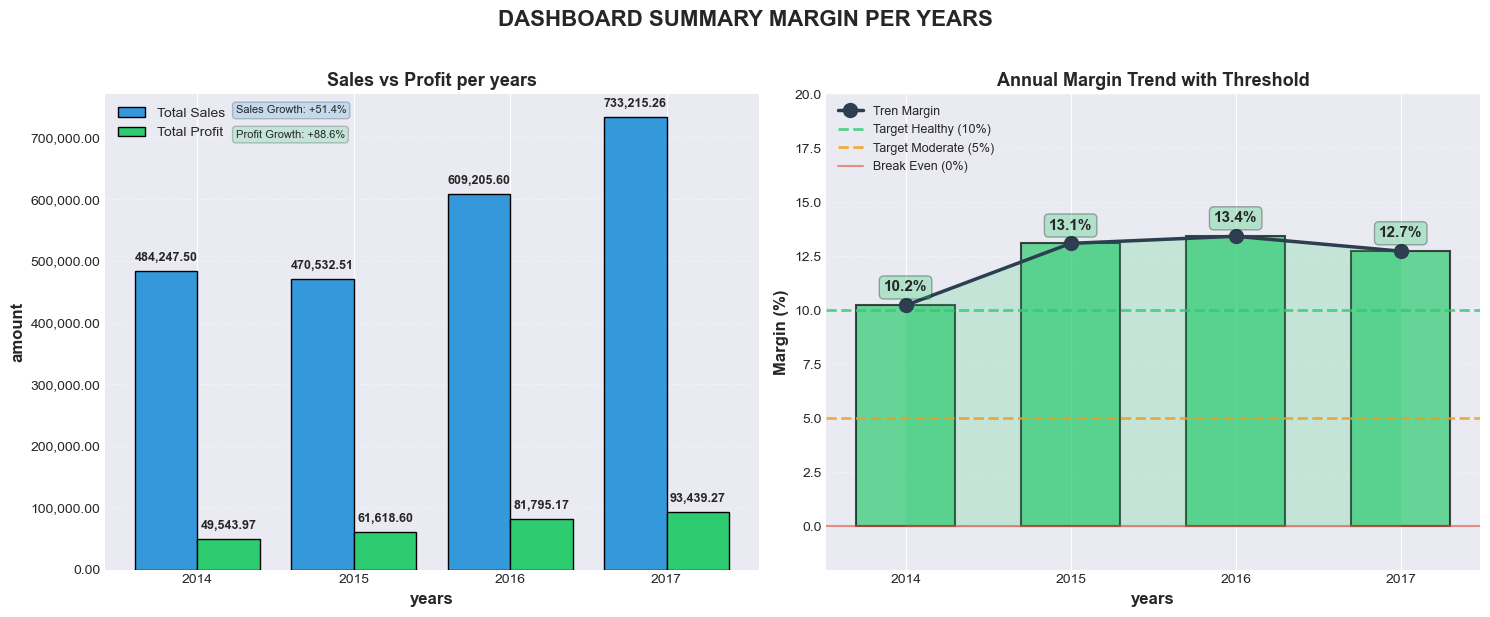

In [40]:
def prepare_numeric_data(df_rmargin):
    
    df_plot = df_rmargin.copy()
    
    # convertion total_sales from string to numeric/ Konversi total_sales dari string ke numeric
    df_plot['total_sales_numeric'] = df_plot['total_sales'].str.replace(',', '').astype(float)
    
    # convertion total_profit from string to numeric/ Konversi total_profit dari string ke numeric
    df_plot['total_profit_numeric'] = df_plot['total_profit'].str.replace(',', '').astype(float)
    
    # convertion total_sales from margin to numeric/ Konversi margin dari string ke numeric
    df_plot['margin_numeric'] = df_plot['margin'].str.replace('%', '').astype(float)
    
    # convertion avg_monthly_margin from string to numeric / Konversi avg_monthly_margin dari string ke numeric
    df_plot['avg_monthly_margin_numeric'] = df_plot['avg_monthly_margin'].str.replace('%', '').astype(float)
    
    return df_plot

#   prepare numeric data / Siapkan data numeric
df_plot = prepare_numeric_data(df_rmargin)


def plot_dashboard_summary_v2(df_plot):

    fig, axes = plt.subplots(1, 2, figsize=(15, 6))
    fig.suptitle('DASHBOARD SUMMARY MARGIN PER YEARS', fontsize=16, fontweight='bold', y=1.02)
    
    # ============ SUBPLOT 1: Sales vs Profit ============
    ax1 = axes[0]
    x = np.arange(len(df_plot['years']))
    width = 0.4
    
    # Plot bars
    bars1 = ax1.bar(x - width/2, df_plot['total_sales_numeric'], width, 
                    label='Total Sales', color='#3498db', edgecolor='black', linewidth=1)
    bars2 = ax1.bar(x + width/2, df_plot['total_profit_numeric'], width, 
                    label='Total Profit', color='#2ecc71', edgecolor='black', linewidth=1)
    
    # value annotation / anotasi nilai
    for bar in bars1:
        height = bar.get_height()
        ax1.annotate(f'{height:,.2f}',
                    xy=(bar.get_x() + bar.get_width()/2, height),
                    xytext=(0, 5), textcoords="offset points",
                    ha='center', va='bottom', fontsize=9, fontweight='bold')
    
    for bar in bars2:
        height = bar.get_height()
        ax1.annotate(f'{height:,.2f}',
                    xy=(bar.get_x() + bar.get_width()/2, height),
                    xytext=(0, 5), textcoords="offset points",
                    ha='center', va='bottom', fontsize=9, fontweight='bold')
    
    # Calculate growth / Hitung growth
    if len(df_plot) >= 2:
        sales_growth = ((df_plot['total_sales_numeric'].iloc[-1] - df_plot['total_sales_numeric'].iloc[0]) / df_plot['total_sales_numeric'].iloc[0]) * 100
        profit_growth = ((df_plot['total_profit_numeric'].iloc[-1] - df_plot['total_profit_numeric'].iloc[0]) / df_plot['total_profit_numeric'].iloc[0]) * 100
        
        ax1.text(0.20, 0.9599, f'Sales Growth: {sales_growth:+.1f}%', 
                transform=ax1.transAxes, fontsize=8, bbox=dict(boxstyle='round', facecolor='#3498db', alpha=0.2))
        ax1.text(0.2, 0.909, f'Profit Growth: {profit_growth:+.1f}%', 
                transform=ax1.transAxes, fontsize=8, bbox=dict(boxstyle='round', facecolor='#2ecc71', alpha=0.2))
    
    ax1.yaxis.set_major_formatter(ticker.FuncFormatter(lambda y, p: f'{y:,.2f}'))
    ax1.set_xlabel('years', fontsize=12, fontweight='bold')
    ax1.set_ylabel('amount', fontsize=12, fontweight='bold')
    ax1.set_title('Sales vs Profit per years', fontsize=13, fontweight='bold')
    ax1.set_xticks(x)
    ax1.set_xticklabels(df_plot['years'].astype(int))
    ax1.legend(loc='upper left', fontsize=10)
    ax1.grid(axis='y', alpha=0.3, linestyle='--')
    
    # ============ SUBPLOT 2: Margin Trend ============
    ax2 = axes[1]
    
    # Bar color based on margin value / Warna bar berdasarkan nilai margin
    colors_margin = ['#2ecc71' if m >= 10 else '#f39c12' if m >= 5 else '#e74c3c' for m in df_plot['margin_numeric']]
    
    # Bar chart
    bars = ax2.bar(df_plot['years'], df_plot['margin_numeric'], 
                   color=colors_margin, edgecolor='black', linewidth=1.5, alpha=0.7, width=0.6)
    
    # Line chart
    ax2.plot(df_plot['years'], df_plot['margin_numeric'], 
             marker='o', linewidth=2.5, markersize=10, 
             color='#2c3e50', label='Tren Margin', zorder=3)
    
    # Add margin value annotation / Tambahkan anotasi nilai margin
    for i, (year, margin, status) in enumerate(zip(df_plot['years'], df_plot['margin_numeric'], df_plot['status'])):
        
        # Add background color to annotation / Tambahkan background color pada anotasi
        bg_color = '#2ecc71' if margin >= 10 else '#f39c12' if margin >= 5 else '#e74c3c'
        ax2.annotate(f'{margin:.1f}%', 
                    xy=(year, margin),
                    xytext=(0, 10), textcoords="offset points",
                    ha='center', fontsize=11, fontweight='bold',
                    bbox=dict(boxstyle='round,pad=0.3', facecolor=bg_color, alpha=0.3))
    
    # Area fill based on threshold
    ax2.fill_between(df_plot['years'], 0, df_plot['margin_numeric'], 
                     alpha=0.2, color='#2ecc71', where=(df_plot['margin_numeric'] >= 10))
    ax2.fill_between(df_plot['years'], 0, df_plot['margin_numeric'], 
                     alpha=0.2, color='#f39c12', where=((df_plot['margin_numeric'] >= 5) & (df_plot['margin_numeric'] < 10)))
    ax2.fill_between(df_plot['years'], 0, df_plot['margin_numeric'], 
                     alpha=0.2, color='#e74c3c', where=(df_plot['margin_numeric'] < 5))
    
    # Garis threshold
    ax2.axhline(y=10, color='#2ecc71', linestyle='--', linewidth=2, alpha=0.8, label='Target Healthy (10%)')
    ax2.axhline(y=5, color='#f39c12', linestyle='--', linewidth=2, alpha=0.8, label='Target Moderate (5%)')
    ax2.axhline(y=0, color='#e74c3c', linestyle='-', linewidth=1.5, alpha=0.6, label='Break Even (0%)')
    
    ax2.set_xlabel('years', fontsize=12, fontweight='bold')
    ax2.set_ylabel('Margin (%)', fontsize=12, fontweight='bold')
    ax2.set_title('Annual Margin Trend with Threshold', fontsize=13, fontweight='bold')
    ax2.set_xticks(df_plot['years'])
    ax2.set_xticklabels(df_plot['years'].astype(int))
    ax2.legend(loc='upper left', fontsize=9)
    ax2.grid(axis='y', alpha=0.3, linestyle='--')
    
    # Set y-axis limits
    y_min = min(-2, df_plot['margin_numeric'].min() - 2)
    y_max = max(20, df_plot['margin_numeric'].max() + 5)
    ax2.set_ylim(y_min, y_max)
    
    plt.tight_layout()
    plt.show()
    
    return fig

# Panggil
fig2 = plot_dashboard_summary_v2(df_plot)

In [41]:
#General Sales per years
q_yoy_growth = """
WITH years_aggr AS (
SELECT
    EXTRACT (YEAR FROM order_date) AS years,
    SUM (sales) AS total_sales,
    SUM (profit) AS total_profit,
FROM stores_cleaning
GROUP BY years

), margin_count AS (
SELECT 
    years,
    total_sales,
    total_profit,
    ROUND ((total_profit/total_sales)*100,2) as margin
FROM years_aggr
), yoy AS (

SELECT
    years,
    total_sales,
    total_profit,
    margin,
    LAG (total_sales,1) OVER (ORDER BY years) AS sls_samemonth_ly,
    LAG (total_profit,1) OVER (ORDER BY years) AS prof_samemonth_ly,
    LAG (margin,1) OVER (ORDER BY years) AS margin_samemonth_ly
FROM margin_count

), yoy_count AS (
SELECT 
    years,
    total_sales,
    total_profit,
    margin,
    sls_samemonth_ly,
    prof_samemonth_ly,
    ROUND ((total_sales - sls_samemonth_ly) /NULLIF(sls_samemonth_ly,0) * 100, 2)
    AS yoy_sls_growth_pct,
    ROUND ((total_profit - prof_samemonth_ly) /NULLIF(prof_samemonth_ly,0) * 100, 2)
    AS yoy_prof_growth_pct,
    ROUND (margin - margin_samemonth_ly, 2)  AS yoy_margin_growth_pct
FROM yoy

)
SELECT 
    years,
    total_sales,
    total_profit,
    margin,
    round(yoy_sls_growth_pct,2) as sales_growth,
    round(yoy_prof_growth_pct,2) as profit_growth,
    round(yoy_margin_growth_pct,2) as margin_growth
FROM yoy_count
ORDER BY years


"""
dyoygrowth = duckdb.sql (q_yoy_growth).df()
dyoygrowth

  

,years,total_sales,total_profit,margin,sales_growth,profit_growth,margin_growth
0,2014,484247.4981,49543.9741,10.23,NaN,NaN,NaN
1,2015,470532.5090,61618.6037,13.10,-2.83,24.37,2.87
2,2016,609205.5980,81795.1743,13.43,29.47,32.74,0.33
3,2017,733215.2552,93439.2696,12.74,20.36,14.24,-0.69


In [42]:
def growth_table(dyoygrowth):
    df_report_growth = dyoygrowth.copy()
    
    # Total
    total_sales_all = 0
    total_profit_all = 0
    total_sales_all = df_report_growth['total_sales'].sum()
    total_profit_all = df_report_growth['total_profit'].sum()
    avg_margin_all = (total_profit_all / total_sales_all) * 100 if total_sales_all > 0 else 0
    
    print("\n" + "="*90)
    print("SUMMARY YEAR OVER YEAR GROWTH".center(100))
    print("="*90)
    print(f"Total Sales  : {total_sales_all:>30,.2f}")
    print(f"Total Profit : {total_profit_all:>30,.2f}")
    print(f"Total Average: {avg_margin_all:>30,.2f}%")
    print("-"*90)
    print(f"{'TAHUN':<8} {'TOTAL SALES':>10} {'TOTAL PROFIT':>10} {'MARGIN':>8} {'SALES GROWTH':>14} {'PROFIT GROWTH':>14} {'MARGIN GROWTH':>14}")
    print("-"*90)
    
    # Print Rows / Cetak setiap baris data
    for _, row in df_report_growth.iterrows():
        # Format angka dengan pemisah ribuan
        sales_formatted = f"{row['total_sales']:,.0f}"
        profit_formatted = f"{row['total_profit']:,.0f}"
        margin_formatted = f"{row['margin']:.2f}%"
         
     # Format growth dengan tanda +/-
        sales_growth_formatted = f"{row['sales_growth']:+.2f}%" if pd.notna(row['sales_growth']) else "N/A"
        profit_growth_formatted = f"{row['profit_growth']:+.2f}%" if pd.notna(row['profit_growth']) else "N/A"
        margin_growth_formatted = f"{row['margin_growth']:+.2f}" if pd.notna(row['margin_growth']) else "N/A"
        
        print(f"{int(row['years']):<8} {sales_formatted:>10} {profit_formatted:>10} {margin_formatted:>10} "
              f"{sales_growth_formatted:>12} {profit_growth_formatted:>12} {margin_growth_formatted:>12}")
    
    print("-"*90)

    return  df_report_growth
    
df_summ_growth = growth_table(dyoygrowth)


                                   SUMMARY YEAR OVER YEAR GROWTH                                    
Total Sales  :                   2,297,200.86
Total Profit :                     286,397.02
Total Average:                          12.47%
------------------------------------------------------------------------------------------
TAHUN    TOTAL SALES TOTAL PROFIT   MARGIN   SALES GROWTH  PROFIT GROWTH  MARGIN GROWTH
------------------------------------------------------------------------------------------
2014        484,247     49,544     10.23%          N/A          N/A          N/A
2015        470,533     61,619     13.10%       -2.83%      +24.37%        +2.87
2016        609,206     81,795     13.43%      +29.47%      +32.74%        +0.33
2017        733,215     93,439     12.74%      +20.36%      +14.24%        -0.69
------------------------------------------------------------------------------------------


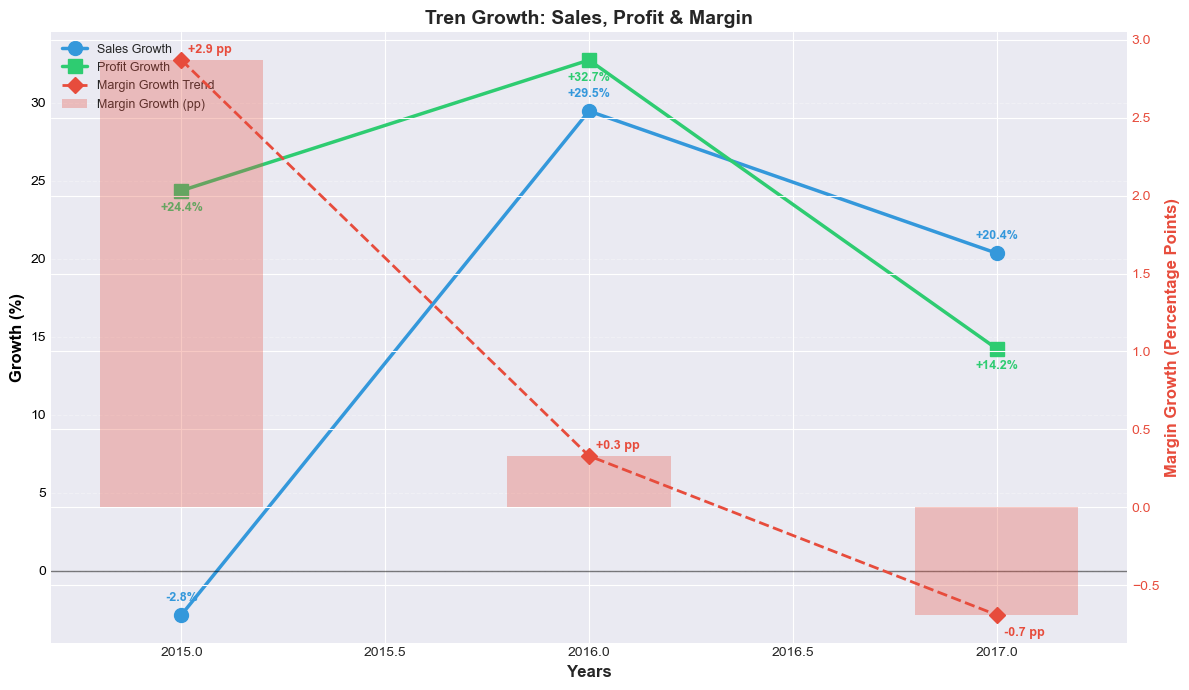

In [43]:
def plot_growth_visualizations(df_report_growth):
    
    # Filter data yang memiliki growth (bukan tahun pertama)
    df_plot = df_report_growth[df_report_growth['sales_growth'].notna()].copy()
    
    if df_plot.empty:
        print(" data not found /data tidak di temukan (min 2 years /min 2 tahun)")
        return None
    
    figures = {}
    
    # VISUALISASI: LINE CHART MULTI-AXIS (Growth + Margin)
    # =========================================================================
    fig2, ax2_left = plt.subplots(figsize=(12, 7))
    
    # Sumbu kiri: Sales & Profit Growth (%)
    ax2_left.plot(df_plot['years'], df_plot['sales_growth'], 
                 marker='o', linewidth=2.5, markersize=10,
                 color='#3498db', label='Sales Growth')
    ax2_left.plot(df_plot['years'], df_plot['profit_growth'], 
                 marker='s', linewidth=2.5, markersize=10,
                 color='#2ecc71', label='Profit Growth')
    ax2_left.axhline(y=0, color='black', linewidth=1, alpha=0.5)
    ax2_left.set_xlabel('Years', fontsize=12, fontweight='bold')
    ax2_left.set_ylabel('Growth (%)', fontsize=12, fontweight='bold', color='black')
    ax2_left.tick_params(axis='y', labelcolor='black')
    ax2_left.grid(axis='y', alpha=0.3, linestyle='--')
    
    # Sumbu kanan: Margin Growth (poin persentase)
    ax2_right = ax2_left.twinx()
    ax2_right.bar(df_plot['years'], df_plot['margin_growth'], 
                 width=0.4, alpha=0.3, color='#e74c3c', label='Margin Growth')
    ax2_right.plot(df_plot['years'], df_plot['margin_growth'], 
                  marker='D', linewidth=2, markersize=8,
                  color='#e74c3c', linestyle='--', label='Margin Growth Trend')
    ax2_right.set_ylabel('Margin Growth (Percentage Points)', fontsize=12, fontweight='bold', color='#e74c3c')
    ax2_right.tick_params(axis='y', labelcolor='#e74c3c')
    
    # Tambahkan anotasi nilai
    for i, (year, sales, profit, margin) in enumerate(zip(df_plot['years'], 
                                                           df_plot['sales_growth'],
                                                           df_plot['profit_growth'],
                                                           df_plot['margin_growth'])):
        ax2_left.annotate(f'{sales:+.1f}%', xy=(year, sales), 
                         xytext=(0, 10), textcoords="offset points",
                         ha='center', fontsize=9, fontweight='bold', color='#3498db')
        ax2_left.annotate(f'{profit:+.1f}%', xy=(year, profit), 
                         xytext=(0, -15), textcoords="offset points",
                         ha='center', fontsize=9, fontweight='bold', color='#2ecc71')
        ax2_right.annotate(f'{margin:+.1f} pp', xy=(year, margin), 
                          xytext=(5, 5 if margin >= 0 else -15), 
                          textcoords="offset points",
                          ha='left', fontsize=9, fontweight='bold', color='#e74c3c')
    
    # Legends kombinasi
    lines1 = ax2_left.get_lines()
    lines2 = ax2_right.get_lines()
    bars2 = ax2_right.patches
    legends = [lines1[0], lines1[1], lines2[0], bars2[0]]
    ax2_left.legend(legends, ['Sales Growth', 'Profit Growth', 'Margin Growth Trend', 'Margin Growth (pp)'],
                   loc='upper left', fontsize=9)
    
    ax2_left.set_title('Tren Growth: Sales, Profit & Margin', fontsize=14, fontweight='bold')
    
    plt.tight_layout()
    figures['multi_axis_growth'] = fig2
    
    plt.show()

print("="*80)

figures = plot_growth_visualizations(df_summ_growth)

##### For Test

                           DATA TYPE SUMMARY                            
 Order Date           → object/varchar → datetime64/TIMESTAMP, DATE 
 Ship Date            → object/varchar → datetime64/TIMESTAMP, DATE 
 Postal Code          → BIGINT/int64 → object/varchar,text 
 Sales                → Double/float64 → decimal 
 Discount             → Double/float64 → decimal 
 Profit               → Double/float64 → decimal 

                    ROW COUNT PER PARTITION SUMMARY                     
         METRIC                VALUE
---------------------------------------------
Total Rows                : 9,994
Unique Order ID           : 5,009
Duplicate Order ID        : 4,985
Unique Customer ID        : 793
Duplicate Customer ID     : 9,201
Unique City               : 531
Duplicate City            : 9,463
Order Earliest Record     : 2014-01-03
Order Lateest Record      : 2017-12-30
Order Span Days           : 1,457
Ship Earliest Record      : 2014-01-07
Ship Lateest Record       : 2018-01-0

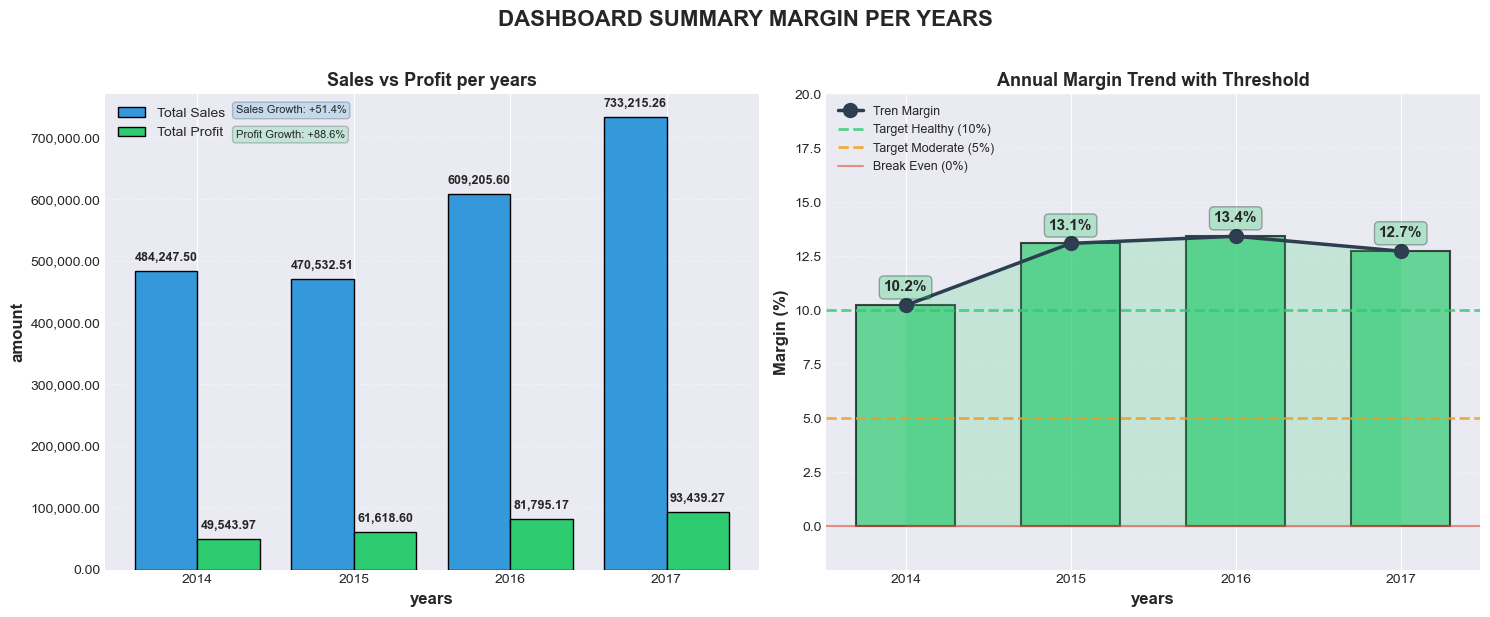

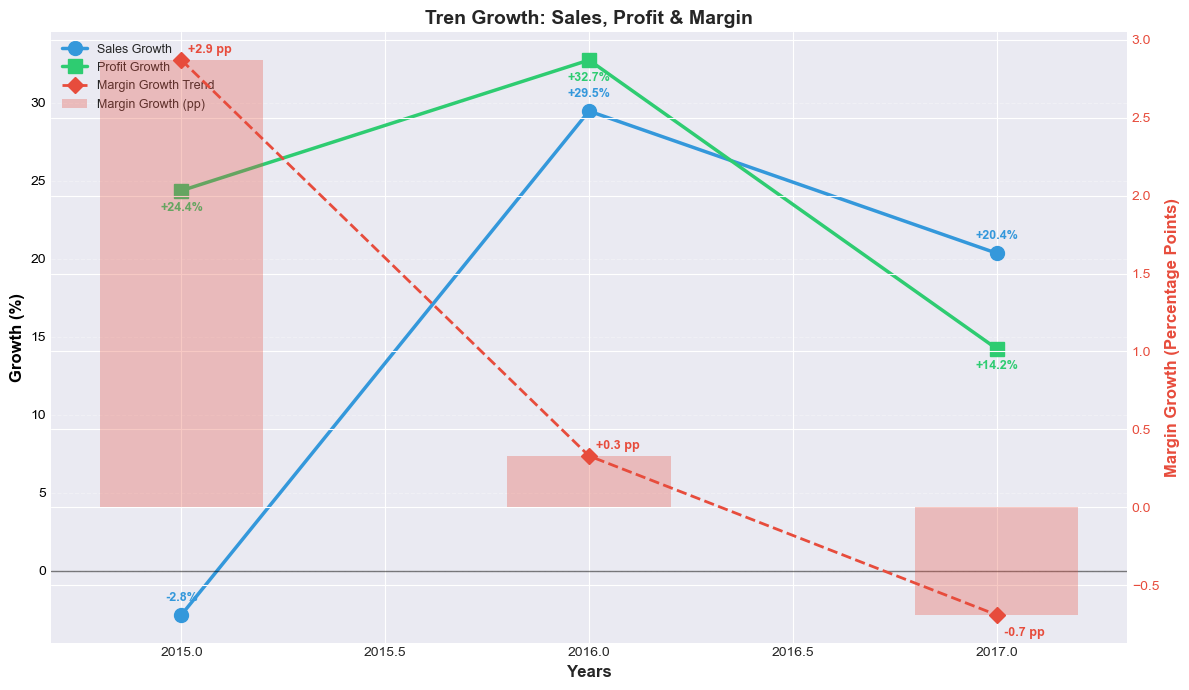

In [45]:
type_summary()
rdate_summary()
cardi_result = car_summ(dcardinality)
df_summ = simple_table(drecmargin)
df_summ_growth = growth_table(dyoygrowth)
fig2 = plot_dashboard_summary_v2(df_plot)
figures = plot_growth_visualizations(df_summ_growth)